# NYC Motor Vehicle Collisions: EDA and Feature Engineering

This notebook performs exploratory data analysis and feature engineering for the NYC Motor Vehicle Collisions final project. The goal is to prepare a cleaned and engineered dataset that can later be used for supervised machine learning classification.

The target variable is whether a crash resulted in at least one injury.

## 1. Import Libraries

In [1]:
import sys
sys.path.append("../src")
from features import run_engineering
from preprocessing import run_prep
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

## 2. Load Dataset

The project dataset is already merged into one file called `merged_sample.csv`.

In [17]:
df = pd.read_csv("../data/raw/merged_sample.csv", low_memory=False)

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (50000, 73)


,crash_date,crash_time,on_street_name,off_street_name,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,number_of_motorist_injured,number_of_motorist_killed,contributing_factor_vehicle_1,contributing_factor_vehicle_2,collision_id,vehicle_type_code1,vehicle_type_code2,borough,zip_code,latitude,longitude,location,contributing_factor_vehicle_3,vehicle_type_code_3,cross_street_name,contributing_factor_vehicle_4,vehicle_type_code_4,contributing_factor_vehicle_5,vehicle_type_code_5,unique_id,crash_date_v,crash_time_v,vehicle_id,state_registration,vehicle_type,contributing_factor_1,vehicle_make,vehicle_year,travel_direction,vehicle_occupants,driver_sex,driver_license_status,driver_license_jurisdiction,pre_crash,point_of_impact,vehicle_damage,public_property_damage,contributing_factor_2,vehicle_damage_1,vehicle_damage_2,vehicle_damage_3,vehicle_model,public_property_damage_type,unique_id_p,crash_date_p,crash_time_p,person_id,person_type,person_injury,vehicle_id_p,ped_role,person_sex,person_age,ejection,emotional_status,bodily_injury,position_in_vehicle,safety_equipment,complaint,ped_location,ped_action,contributing_factor_1_p,contributing_factor_2_p
0,2021-09-11T00:00:00.000,2:39,WHITESTONE EXPRESSWAY,20 AVENUE,2,0,0,0,0,0,2,0,Aggressive Driving/Road Rage,Unspecified,4455765,Sedan,Sedan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-03-26T00:00:00.000,11:45,QUEENSBORO BRIDGE UPPER,NaN,1,0,0,0,0,0,1,0,Pavement Slippery,NaN,4513547,Sedan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-11-01T00:00:00.000,1:29,OCEAN PARKWAY,AVENUE K,1,0,0,0,0,0,1,0,Unspecified,Unspecified,4675373,Moped,Sedan,BROOKLYN,11230.0,40.62179,-73.970024,"{'latitude': '40.62179', 'longitude': '-73.970...",Unspecified,Sedan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-06-29T00:00:00.000,6:55,THROGS NECK BRIDGE,NaN,0,0,0,0,0,0,0,0,Following Too Closely,Unspecified,4541903,Sedan,Pick-up Truck,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-09-21T00:00:00.000,13:21,BROOKLYN BRIDGE,NaN,0,0,0,0,0,0,0,0,Passing Too Closely,Unspecified,4566131,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Standardize Column Names

Column names are standardized to make them easier to use in Python. Spaces are replaced with underscores and all names are converted to lowercase.

In [3]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['crash_date', 'crash_time', 'on_street_name', 'off_street_name', 'number_of_persons_injured', 'number_of_persons_killed', 'number_of_pedestrians_injured', 'number_of_pedestrians_killed', 'number_of_cyclist_injured', 'number_of_cyclist_killed', 'number_of_motorist_injured', 'number_of_motorist_killed', 'contributing_factor_vehicle_1', 'contributing_factor_vehicle_2', 'collision_id', 'vehicle_type_code1', 'vehicle_type_code2', 'borough', 'zip_code', 'latitude', 'longitude', 'location', 'contributing_factor_vehicle_3', 'vehicle_type_code_3', 'cross_street_name', 'contributing_factor_vehicle_4', 'vehicle_type_code_4', 'contributing_factor_vehicle_5', 'vehicle_type_code_5', 'unique_id', 'crash_date_v', 'crash_time_v', 'vehicle_id', 'state_registration', 'vehicle_type', 'contributing_factor_1', 'vehicle_make', 'vehicle_year', 'travel_direction', 'vehicle_occupants', 'driver_sex', 'driver_license_status', 'driver_license_jurisdiction', 'pre_crash', 'point_of_impact', 'vehicle_damage', 'publi

## 4. Basic Dataset Inspection

In [4]:
print("Dataset Info:")
df.info()

print("\nMissing Values:")
display(df.isnull().sum().sort_values(ascending=False).head(25))

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 73 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   crash_date                     50000 non-null  object 
 1   crash_time                     50000 non-null  object 
 2   on_street_name                 36427 non-null  object 
 3   off_street_name                23088 non-null  object 
 4   number_of_persons_injured      50000 non-null  int64  
 5   number_of_persons_killed       50000 non-null  int64  
 6   number_of_pedestrians_injured  50000 non-null  int64  
 7   number_of_pedestrians_killed   50000 non-null  int64  
 8   number_of_cyclist_injured      50000 non-null  int64  
 9   number_of_cyclist_killed       50000 non-null  int64  
 10  number_of_motorist_injured     50000 non-null  int64  
 11  number_of_motorist_killed      50000 non-null  int64  
 12  contributing_factor_vehicle_1  4

contributing_factor_2_p        50000
vehicle_damage_2               50000
vehicle_model                  50000
vehicle_damage_3               50000
point_of_impact                50000
vehicle_damage                 50000
public_property_damage         50000
contributing_factor_2          50000
driver_license_status          50000
driver_license_jurisdiction    50000
pre_crash                      50000
public_property_damage_type    50000
driver_sex                     50000
contributing_factor_1_p        50000
ped_action                     50000
ped_location                   50000
vehicle_make                   50000
vehicle_year                   50000
travel_direction               50000
vehicle_occupants              50000
vehicle_damage_1               50000
unique_id                      50000
crash_date_v                   50000
crash_time_v                   50000
contributing_factor_1          50000
dtype: int64


Duplicate Rows:


0


## 5. Create Target Variable

The target variable is called `injury_occurred`. It equals 1 if at least one person was injured in the crash, and 0 otherwise.

In [5]:
injury_col = "number_of_persons_injured"

if injury_col not in df.columns:
    raise ValueError(f"Expected column '{injury_col}' was not found. Check the column names above.")

df["injury_occurred"] = (df[injury_col] > 0).astype(int)

print("Target Distribution:")
display(df["injury_occurred"].value_counts())

print("Target Percentage:")
display(df["injury_occurred"].value_counts(normalize=True) * 100)

Target Distribution:


injury_occurred
0    32367
1    17633
Name: count, dtype: int64

Target Percentage:


injury_occurred
0    64.734
1    35.266
Name: proportion, dtype: float64

## 6. EDA: Injury Distribution

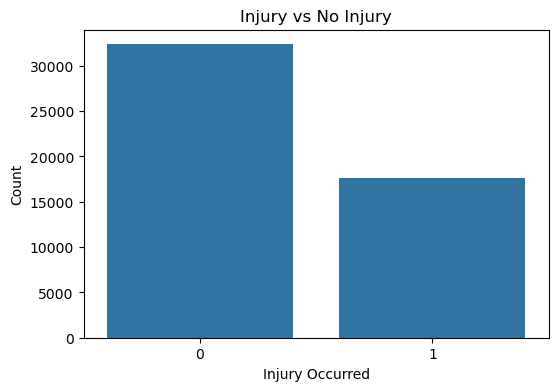

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="injury_occurred")
plt.title("Injury vs No Injury")
plt.xlabel("Injury Occurred")
plt.ylabel("Count")
plt.show()

## 7. Feature Engineering: Date and Time Features

New time-based features are created from `crash_date` and `crash_time`, including crash hour, day of week, and month.

In [7]:
df["crash_date"] = pd.to_datetime(df["crash_date"], errors="coerce")

df["crash_time"] = pd.to_datetime(
    df["crash_time"],
    format="%H:%M",
    errors="coerce"
)

df["hour"] = df["crash_time"].dt.hour
df["day_name"] = df["crash_date"].dt.day_name()
df["month"] = df["crash_date"].dt.month

display(df[["crash_date", "crash_time", "hour", "day_name", "month"]].head())

,crash_date,crash_time,hour,day_name,month
0,2021-09-11,1900-01-01 02:39:00,2,Saturday,9
1,2022-03-26,1900-01-01 11:45:00,11,Saturday,3
2,2023-11-01,1900-01-01 01:29:00,1,Wednesday,11
3,2022-06-29,1900-01-01 06:55:00,6,Wednesday,6
4,2022-09-21,1900-01-01 13:21:00,13,Wednesday,9


## 8. EDA: Crash Frequency by Hour

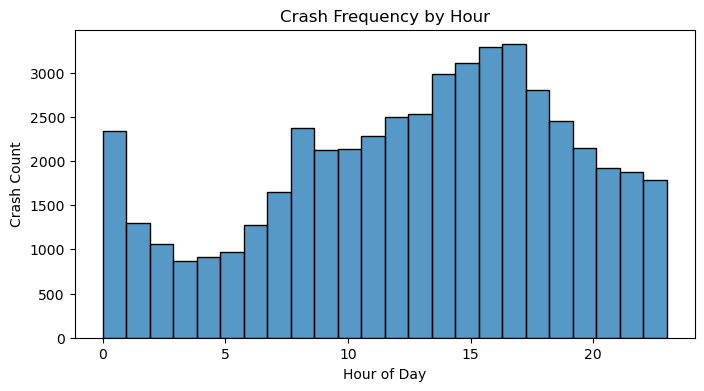

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(df["hour"].dropna(), bins=24)
plt.title("Crash Frequency by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Crash Count")
plt.show()

## 9. EDA: Crashes by Day of Week

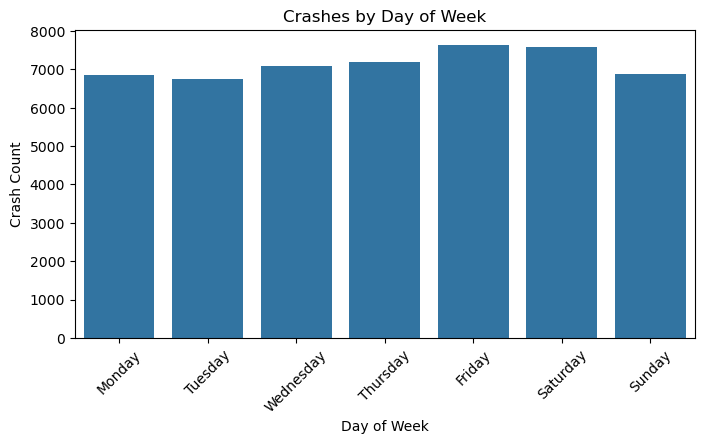

In [9]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="day_name", order=day_order)
plt.title("Crashes by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Crash Count")
plt.xticks(rotation=45)
plt.show()

## 10. EDA: Borough Analysis

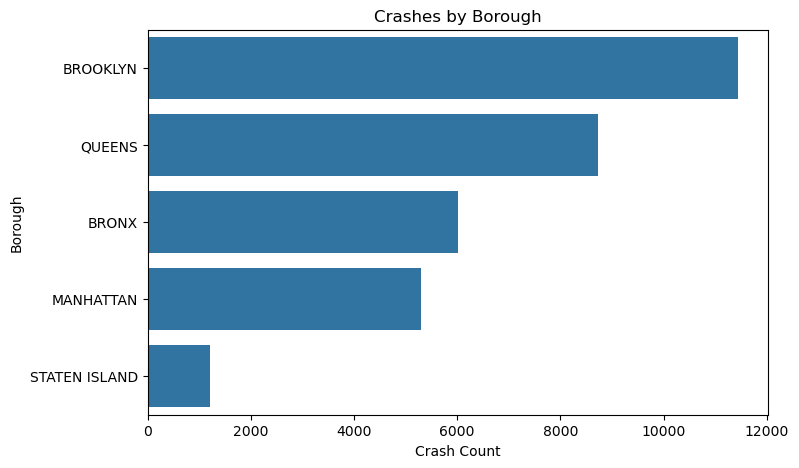

In [10]:
if "borough" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(
        data=df,
        y="borough",
        order=df["borough"].value_counts().index
    )
    plt.title("Crashes by Borough")
    plt.xlabel("Crash Count")
    plt.ylabel("Borough")
    plt.show()
else:
    print("No borough column found. Skipping borough count plot.")

## 11. EDA: Injury Rate by Borough

borough
BROOKLYN         0.353116
MANHATTAN        0.337667
QUEENS           0.334173
STATEN ISLAND    0.327572
BRONX            0.327406
Name: injury_occurred, dtype: float64

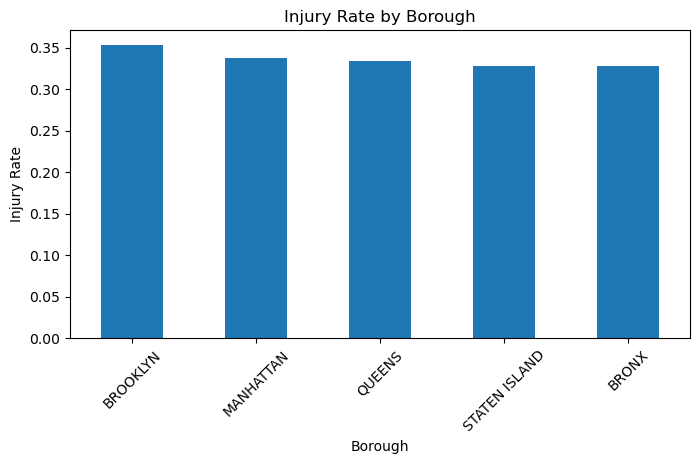

In [11]:
if "borough" in df.columns:
    borough_rates = (
        df.groupby("borough")["injury_occurred"]
        .mean()
        .sort_values(ascending=False)
    )

    display(borough_rates)

    plt.figure(figsize=(8, 4))
    borough_rates.plot(kind="bar")
    plt.title("Injury Rate by Borough")
    plt.xlabel("Borough")
    plt.ylabel("Injury Rate")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("No borough column found. Skipping injury rate by borough.")

## 12. Feature Engineering: Rush Hour and Weekend Features

Two binary features are created:

- `rush_hour`: 1 if the crash happened during common morning or evening commute hours
- `is_weekend`: 1 if the crash happened on Saturday or Sunday

In [12]:
# Calling consolidated feature engineering from src/features.py
df = run_engineering(df)
display(df[["hour", "is_rush_hour", "day_name", "is_weekend"]].head())


,hour,is_rush_hour,day_name,is_weekend
0,2,0,Saturday,1
1,11,0,Saturday,1
2,1,0,Wednesday,0
3,6,0,Wednesday,0
4,13,0,Wednesday,0


## 13. EDA: Vehicle Type and Person Type

These checks are included only if the merged dataset contains vehicle or person-related columns.

No vehicle_type_code column found. Skipping vehicle type plot.


person_type
Occupant    2
Name: count, dtype: int64

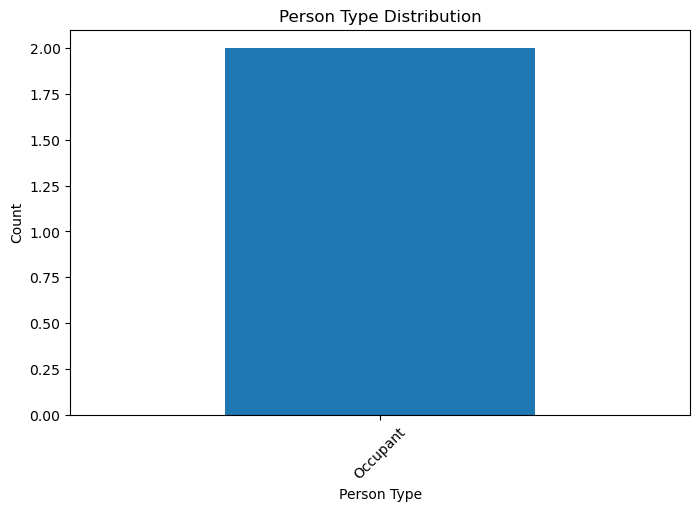

In [13]:
if "vehicle_type_code" in df.columns:
    top_vehicles = (
        df["vehicle_type_code"]
        .dropna()
        .astype(str)
        .str.strip()
        .replace("", np.nan)
        .dropna()
        .value_counts()
        .head(10)
    )

    if len(top_vehicles) > 0:
        display(top_vehicles)

        plt.figure(figsize=(8, 5))
        top_vehicles.plot(kind="bar")
        plt.title("Top 10 Vehicle Types")
        plt.xlabel("Vehicle Type")
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.show()
    else:
        print("vehicle_type_code column exists, but no usable values were found.")
else:
    print("No vehicle_type_code column found. Skipping vehicle type plot.")


if "person_type" in df.columns:
    person_type_counts = (
        df["person_type"]
        .dropna()
        .astype(str)
        .str.strip()
        .replace("", np.nan)
        .dropna()
        .value_counts()
        .head(10)
    )

    if len(person_type_counts) > 0:
        display(person_type_counts)

        plt.figure(figsize=(8, 5))
        person_type_counts.plot(kind="bar")
        plt.title("Person Type Distribution")
        plt.xlabel("Person Type")
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.show()
    else:
        print("person_type column exists, but no usable values were found.")
else:
    print("No person_type column found. Skipping person type plot.")

## 14. Missing Value Handling

Missing categorical values are filled with `Unknown`. Missing numeric values are filled with 0 for this initial feature engineering stage.

In [14]:
categorical_cols = df.select_dtypes(include="object").columns
numeric_cols = df.select_dtypes(include=np.number).columns

df[categorical_cols] = df[categorical_cols].fillna("Unknown")
df[numeric_cols] = df[numeric_cols].fillna(0)

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


## 15. Final Engineered Feature Preview

In [15]:
selected_features = [
    "injury_occurred",
    "hour",
    "day_name",
    "month",
    "is_rush_hour",
    "is_weekend",
    "borough",
    "vehicle_type_code"
]

existing_features = [col for col in selected_features if col in df.columns]

display(df[existing_features].head())

print("Final Dataset Shape:", df.shape)

,injury_occurred,hour,day_name,month,is_rush_hour,is_weekend,borough
0,1,2,Saturday,9,0,1,Unknown
1,1,11,Saturday,3,0,1,Unknown
2,1,1,Wednesday,11,0,0,BROOKLYN
3,0,6,Wednesday,6,0,0,Unknown
4,0,13,Wednesday,9,0,0,Unknown


Final Dataset Shape: (50000, 80)


## 16. Save Engineered Dataset

The engineered dataset is saved as `engineered_collisions.csv` so the next step of the project can use it for model training.

In [16]:
df.to_csv("engineered_collisions.csv", index=False)

print("Saved engineered_collisions.csv")

Saved engineered_collisions.csv


## 17. Summary

In this notebook, the merged NYC Motor Vehicle Collisions dataset was loaded, inspected, and prepared for modeling. A binary injury target was created, basic crash patterns were explored, and new time-based features were engineered. The final engineered dataset was saved for the model training stage of the project.